# B-4703.24001B — AutoML FULL (documentação de resultado FRACO)

Task `d7375726` (full, 4.932 trials, **--select-by heldout**). Falha: 01/out/2022 — desgaste do
mancal LNA do motor elétrico.

**Resultado: melhor trial = VAE/baseline/p99/deb4 → 0,8% de detecção @ ~1% FP held-out** — nível
de ruído. Só 25 de 4.932 trials passaram a constraint honesta, todos ≤0,8% de detecção.

**Confirma a triagem det×FP**: desgaste de rolamento/mancal exige **espectro de vibração**
(BPFO/BPFI/BSF — envelope/FFT); o RMS de banda larga a 1 min não captura a assinatura.
O equipamento fica documentado como NÃO-viável com a instrumentação atual
(ver `docs/auditoria_pdm.md` — cobertura sensor↔modo-de-falha).

In [7]:
import sys; from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from clearml import Task
PROJECT_ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'pyproject.toml').exists()),Path.cwd())
sys.path.insert(0,str(PROJECT_ROOT/'src'))
from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing

In [8]:
EQUIPMENT_ID='B-4703.24001B'; AUTOML_TASK_ID='d7375726eccc4bfbae650d329be59eb3'
EVENT_TS_F1=pd.Timestamp('2022-10-01 00:00'); EVENT_LABEL_F1='Falha (01/Out/2022)'
PREFAILURE_DAYS=30; NORMAL_END_DAYS=60
KEY_SENSORS=['Vibração Motor LNA X','Vibração Motor LNA Y','Temperatura Motor LNA']
SAVE_PLOTS=False

In [9]:
def load_scores(task_id):
    task=Task.get_task(task_id=task_id)
    s=task.artifacts['best_full_scores'].get(); s.index=pd.to_datetime(s.index); s=s.sort_index()
    s['is_anomaly']=s['is_anomaly'].astype(bool)
    res=task.artifacts['automl_results'].get() if 'automl_results' in task.artifacts else None
    bt=task.artifacts['best_trial'].get() if 'best_trial' in task.artifacts else None
    return s[['reconstruction_error','is_anomaly']],res,bt,task
def persistence_filter(flags,k,n):
    if k==1 and n==1: return flags.astype(bool)
    return (flags.astype(int).rolling(window=n,min_periods=n).sum()>=k).fillna(False).astype(bool)
def load_plot_base(eq):
    cfg=EQUIPMENT_CONFIGS[eq]; df_raw=load_equipment_data(eq,from_clearml=False)
    df_base,_,_=run_preprocessing(df_raw,cfg.pre_split_steps,fitted_scaler=None) if cfg.pre_split_steps else (df_raw,None,None)
    df_base=df_base.sort_index(); df_base.index=pd.to_datetime(df_base.index); return df_base,cfg
def model_info_str(bt):
    t=bt['trial']; r=bt['results']
    return (f"Modelo AutoML: {str(t.get('model')).upper()} / {t.get('preset')} / p{t.get('threshold_percentile')} / "
            f"debounce {t.get('debounce_consecutive')}  ·  pré-falha {r.get('prefailure_alert_rate',0):.1%} @ FP {r.get('normal_alert_rate',0):.1%}")

def plot_separated(df_window,scores_window,sensors,threshold,k,n,event_ts,event_label,
                   title_prefix,threshold_label='Limiar',model_info=''):
    plt.style.use('seaborn-v0_8-whitegrid')
    flags=persistence_filter(scores_window['reconstruction_error']>threshold,k=k,n=n)
    anom_idx=scores_window.index[flags]
    for col in list(sensors)+['__score__']:
        fig,ax=plt.subplots(figsize=(14,3.2))
        if col=='__score__':
            y=scores_window['reconstruction_error']; ax.plot(y.index,y,color='purple',lw=0.9,alpha=0.6,label='Score')
            ax.axhline(threshold,color='red',ls='--',lw=1.2,label=threshold_label)
            if len(anom_idx): ax.scatter(anom_idx,y.reindex(anom_idx),s=28,color='red',zorder=4,label='Alerta')
            ax.set_ylabel('Score'); ttl='Score de Anomalia'
        else:
            if col not in df_window.columns: plt.close(fig); continue
            ax.plot(df_window.index,df_window[col],color='steelblue',lw=1.0,alpha=0.85,label=col)
            av=df_window[col].reindex(anom_idx).dropna()
            if not av.empty: ax.scatter(av.index,av.values,s=28,color='red',zorder=4,label='Anomalia')
            ax.set_ylabel(col,fontsize=9); ttl=col
        ax.axvline(event_ts,color='orange',ls='--',lw=1.4,label=event_label)
        ax.set_xlabel('Tempo'); ax.legend(loc='upper left',fontsize=8)
        ax.set_title(f'{title_prefix} | {ttl}',fontsize=12,fontweight='bold')
        if model_info: ax.text(0.5,1.10,model_info,transform=ax.transAxes,ha='center',fontsize=8,color='dimgray')
        fig.tight_layout(); plt.show()

In [10]:
scores,automl_results,bt,task=load_scores(AUTOML_TASK_ID); df_base,cfg=load_plot_base(EQUIPMENT_ID)
MODEL_INFO=model_info_str(bt)
print('Task:',task.name,'| status:',task.get_status(),'| trials viáveis no ranking:',len(automl_results))
print(MODEL_INFO); print('scores:',scores.index.min(),'->',scores.index.max())

Task: automl-b4703.24001B-test | status: completed | trials viáveis no ranking: 25
Modelo AutoML: VAE / baseline / p99.0 / debounce 4  ·  pré-falha 0.8% @ FP 0.7%
scores: 2022-01-28 15:10:00 -> 2022-10-26 16:05:00


## Ranking (todos com detecção ≤0,8% — nível de ruído)

In [11]:
cols=[x for x in ['model','preset','threshold_percentile','debounce_consecutive','prefailure_alert_rate','normal_alert_rate','val_fp_rate_heldout'] if x in automl_results.columns]
fmt={k:'{:.2%}' for k in ['prefailure_alert_rate','normal_alert_rate','val_fp_rate_heldout']}; fmt['threshold_percentile']='{:.1f}'
display(automl_results[cols].head(10).style.format({k:v for k,v in fmt.items() if k in cols}))
print('Detecção máxima @ FP held-out <=1%:', f"{automl_results['prefailure_alert_rate'].max():.1%}")

,model,preset,threshold_percentile,debounce_consecutive,prefailure_alert_rate,normal_alert_rate,val_fp_rate_heldout
0,vae,baseline,99.0,4,0.79%,0.75%,0.98%
1,lstm,baseline,99.0,1,0.59%,1.15%,0.74%
2,lstm,baseline,99.0,6,0.54%,0.42%,0.74%
3,vae,baseline,99.0,4,0.44%,0.73%,0.55%
4,vae,baseline,99.0,4,0.12%,0.71%,0.15%
5,vae,baseline,99.0,4,0.05%,0.70%,0.06%
6,vae,baseline,99.0,1,0.00%,1.15%,0.00%
7,vae,baseline,99.0,1,0.00%,1.12%,0.00%
8,vae,baseline,99.0,1,0.00%,1.15%,0.00%
9,vae,baseline,99.0,1,0.00%,1.15%,0.00%


Detecção máxima @ FP held-out <=1%: 0.8%


## Zoom 30 dias antes da falha — os sensores não mostram precursor

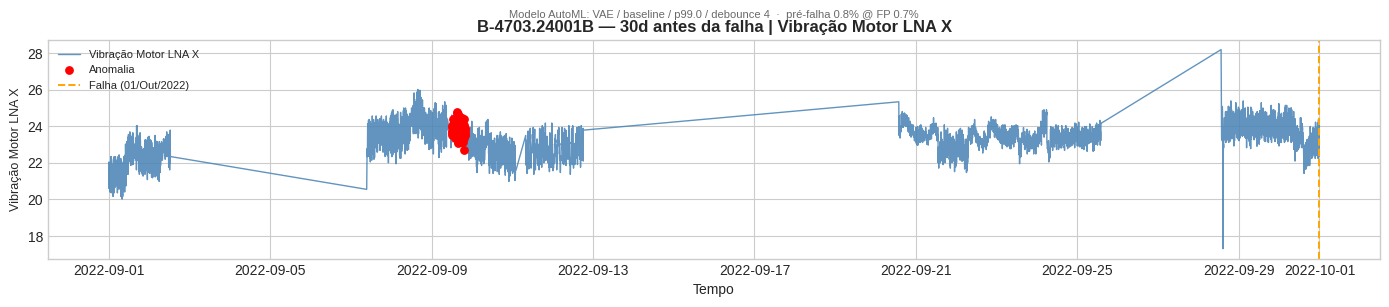

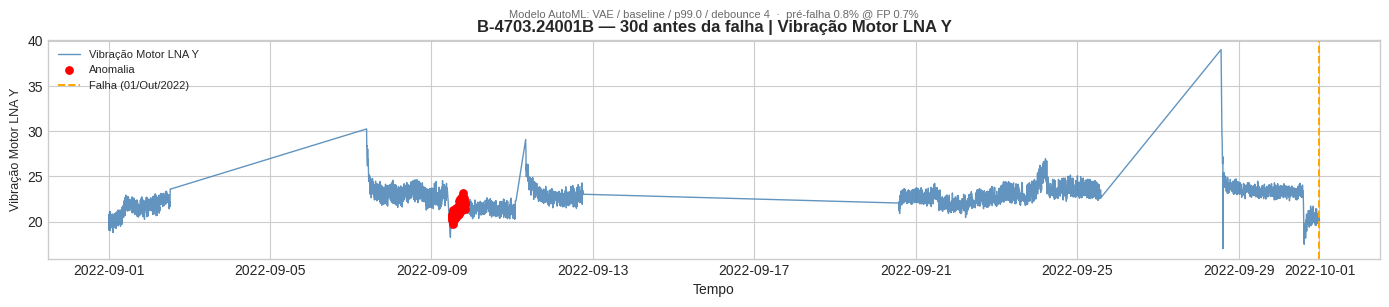

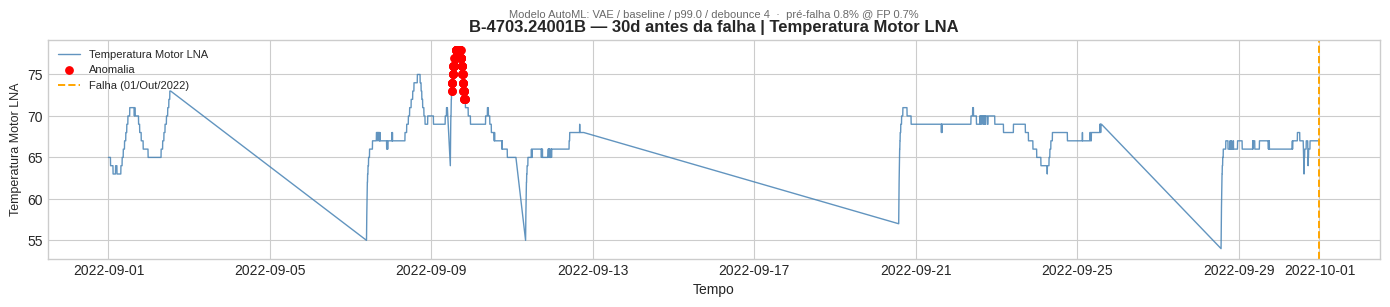

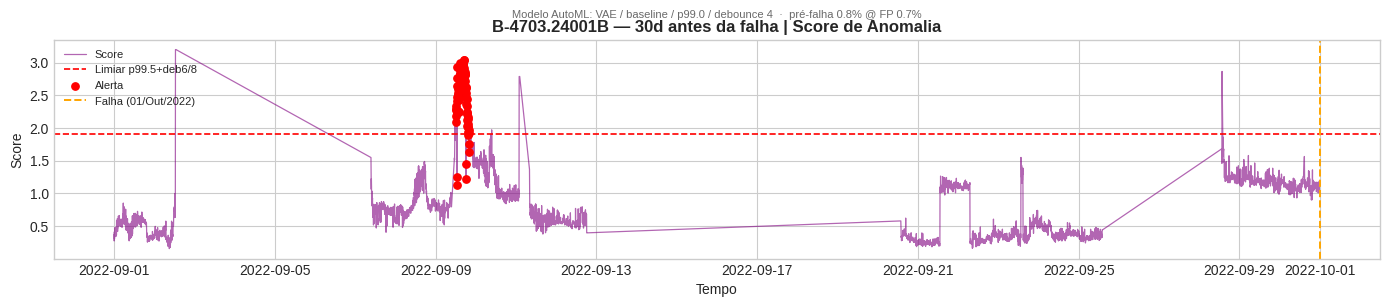

Note: vibração/temperatura do mancal LNA do motor sem rampa visível — o desgaste não aparece no RMS 1min.


In [12]:
_e=scores['reconstruction_error']; _ne=EVENT_TS_F1-pd.Timedelta(days=NORMAL_END_DAYS); _mn=scores.index<_ne
selected_threshold=float(np.percentile(_e[_mn].values,99.5)); selected_k,selected_n=6,8
threshold_label='Limiar p99.5+deb6/8'
z=EVENT_TS_F1-pd.Timedelta(days=30)
dfw=df_base.loc[z:EVENT_TS_F1]; sw=scores.loc[z:EVENT_TS_F1]
common=dfw.index.intersection(sw.index); dfw,sw=dfw.loc[common],sw.loc[common]
sensors=[s for s in KEY_SENSORS if s in dfw.columns]
plot_separated(dfw,sw,sensors,selected_threshold,selected_k,selected_n,EVENT_TS_F1,EVENT_LABEL_F1,
               title_prefix=f'{EQUIPMENT_ID} — 30d antes da falha',threshold_label=threshold_label,model_info=MODEL_INFO)
print('Note: vibração/temperatura do mancal LNA do motor sem rampa visível — o desgaste não aparece no RMS 1min.')

## Série completa — o score não separa a pré-falha do normal

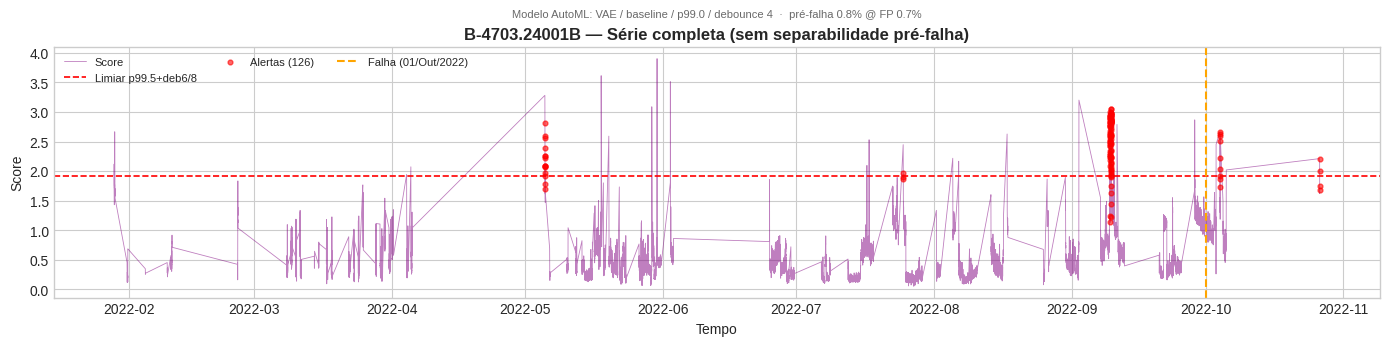

re-threshold p99.5+6/8: detecção pré-falha=2.3% | FP normal=0.16%
Conclusão: indistinguível do ruído — consistente com a triagem (~1% de separabilidade).


In [13]:
plt.style.use('seaborn-v0_8-whitegrid')
_e=scores['reconstruction_error']; _ne=EVENT_TS_F1-pd.Timedelta(days=NORMAL_END_DAYS); _mn=scores.index<_ne
_mp=(scores.index>=EVENT_TS_F1-pd.Timedelta(days=PREFAILURE_DAYS))&(scores.index<EVENT_TS_F1)
selected_threshold=float(np.percentile(_e[_mn].values,99.5)); selected_k,selected_n=6,8
flags=persistence_filter(_e>selected_threshold,selected_k,selected_n)
fig,ax=plt.subplots(figsize=(14,3.6))
ax.plot(scores.index,_e,color='purple',lw=0.6,alpha=0.5,label='Score')
ax.axhline(selected_threshold,color='red',ls='--',lw=1.2,label='Limiar p99.5+deb6/8')
idx=scores.index[flags]; ax.scatter(idx,_e[idx],s=12,color='red',alpha=0.6,zorder=4,label=f'Alertas ({len(idx)})')
ax.axvline(EVENT_TS_F1,color='orange',ls='--',lw=1.5,label=EVENT_LABEL_F1)
ax.set_ylabel('Score'); ax.set_xlabel('Tempo'); ax.legend(loc='upper left',fontsize=8,ncol=3)
ax.set_title(f'{EQUIPMENT_ID} — Série completa (sem separabilidade pré-falha)',fontweight='bold')
ax.text(0.5,1.12,MODEL_INFO,transform=ax.transAxes,ha='center',fontsize=8,color='dimgray')
fig.tight_layout(); plt.show()
print(f're-threshold p99.5+6/8: detecção pré-falha={flags[_mp].mean():.1%} | FP normal={flags[_mn].mean():.2%}')
print('Conclusão: indistinguível do ruído — consistente com a triagem (~1% de separabilidade).')

## Conclusão
- **Não-viável** com a instrumentação atual: detecção ≤0,8% @ FP <=1% (held-out) em 4.932 trials.
- Causa física: desgaste de mancal/rolamento se manifesta em **bandas de frequência específicas**
  (BPFO/BPFI/BSF) — exige waveform de alta taxa (envelope/FFT), não RMS a 1 min.
- Recomendação: registrar como lacuna de instrumentação; não investir mais modelagem.